In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay

from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import AUC, Precision, Recall

import shap
import lime
import lime.lime_tabular

import warnings
warnings.filterwarnings("ignore")

In [23]:
import pickle

with open("/kaggle/input/datasets/janaelsawyy/xa-data/train_xai_ready.pkl", "rb") as f:
    train_df = pickle.load(f)

with open("/kaggle/input/datasets/janaelsawyy/xa-data/test_xai_ready.pkl", "rb") as f:
    test_df = pickle.load(f)

# Target column
TARGET = "SepsisLabel"

# Split features and target
X = train_df.drop(columns=[TARGET])
y = train_df[TARGET]

X_test = test_df.drop(columns=[TARGET])
y_test = test_df[TARGET]

FEATURES = X.columns.tolist()

print(f"\n  Train : {X.shape[0]:>6,} rows | "
      f"Sepsis={y.sum():,} ({y.mean()*100:.1f}%)")

print(f"  Test  : {X_test.shape[0]:>6,} rows | "
      f"Sepsis={y_test.sum():,} ({y_test.mean()*100:.1f}%)")

print(f"  Features: {len(FEATURES)}")


  Train : 59,844 rows | Sepsis=29,922 (50.0%)
  Test  :  8,068 rows | Sepsis=586 (7.3%)
  Features: 30


In [24]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("\nTrain Shape:", X_train.shape)
print("Validation Shape:", X_valid.shape)
print("Test Shape:", X_test.shape)


Train Shape: (47875, 30)
Validation Shape: (11969, 30)
Test Shape: (8068, 30)


# BUILDING THE MLP MODEL

In [47]:
model = Sequential([

    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.5),

    Dense(32, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')

])

In [48]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        Precision(name='precision'),
        Recall(name='recall'),
        AUC(name='auc')
    ]
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

In [49]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
)

In [50]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_valid, y_valid),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
1497/1497 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.6486 - auc: 0.7088 - loss: 0.6295 - precision: 0.6559 - recall: 0.6423 - val_accuracy: 0.8020 - val_auc: 0.8880 - val_loss: 0.4407 - val_precision: 0.7935 - val_recall: 0.8163
Epoch 2/50
1497/1497 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7734 - auc: 0.8555 - loss: 0.4790 - precision: 0.7867 - recall: 0.7458 - val_accuracy: 0.8264 - val_auc: 0.9096 - val_loss: 0.3965 - val_precision: 0.8257 - val_recall: 0.8274
Epoch 3/50
1497/1497 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8019 - auc: 0.8829 - loss: 0.4454 - precision: 0.8114 - recall: 0.7835 - val_accuracy: 0.8378 - val_auc: 0.9184 - val_loss: 0.3762 - val_precision: 0.8413 - val_recall: 0.8327
Epoch 4/50
1497/1497 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8155 - auc: 0.8943 - loss: 0.4203 - precision: 0.8210 - recall: 0.8043 - val_accuracy: 0.8411 - val_auc: 0.9233 - val_loss: 0.3687 - val_precision: 0.8592 - val_recall: 0.8158
Epoch 5/50
1497/1497 ━━

# PLOT TRAINING HISTORY

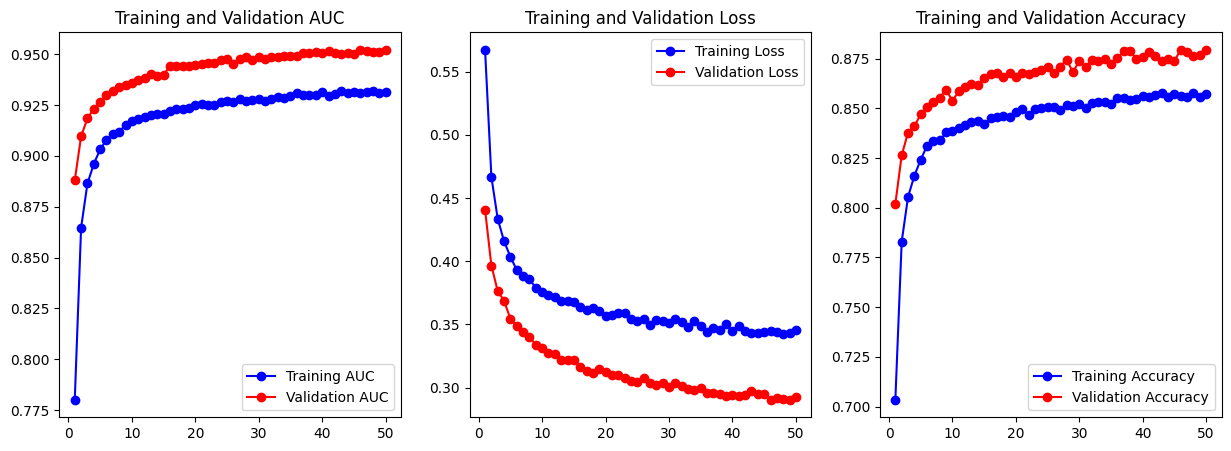

In [51]:
import matplotlib.pyplot as plt

def plot_learning_curves(history):
    
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    auc = history.history['auc']
    val_auc = history.history['val_auc']
    
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(15, 5))

    # Plot AUC
    plt.subplot(1, 3, 1)
    plt.plot(epochs, auc, 'bo-', label='Training AUC')
    plt.plot(epochs, val_auc, 'ro-', label='Validation AUC')
    plt.title('Training and Validation AUC')
    plt.legend()

    # Plot Loss
    plt.subplot(1, 3, 2)
    plt.plot(epochs, loss, 'bo-', label='Training Loss')
    plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.legend()

    # Plot Accuracy
    plt.subplot(1, 3, 3)
    plt.plot(epochs, acc, 'bo-', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()

    plt.show()

plot_learning_curves(history)

# THRESHOLD OPTIMIZATION

253/253 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
 Threshold for max F1: 0.746
📈 Threshold for ≥70% Precision: 0.853


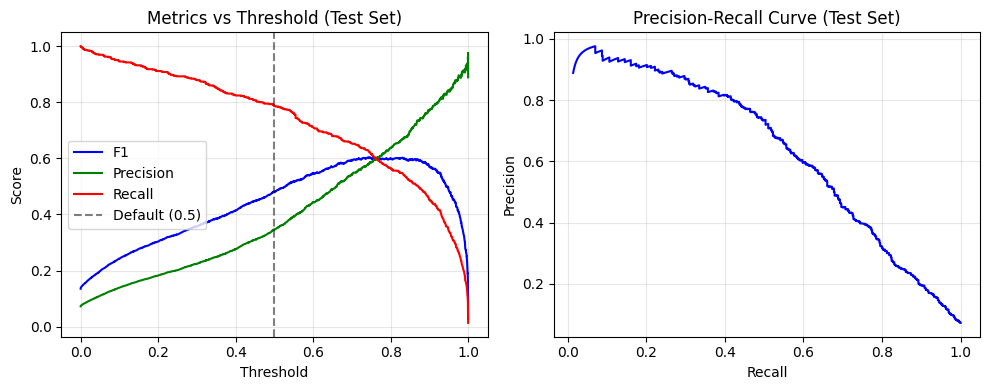

In [59]:
import numpy as np
from sklearn.metrics import precision_recall_curve, f1_score
import matplotlib.pyplot as plt

y_test_proba = model.predict(X_test).flatten()
precision, recall, thresholds = precision_recall_curve(y_test, y_test_proba)
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-7)

# Find key thresholds
thresh_max_f1 = thresholds[np.argmax(f1_scores)]
prec_above_70 = thresholds[np.where(precision[:-1] >= 0.70)[0][0]] if any(precision[:-1] >= 0.70) else None

print(f" Threshold for max F1: {thresh_max_f1:.3f}")
if prec_above_70:
    print(f"📈 Threshold for ≥70% Precision: {prec_above_70:.3f}")

# Visualize
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(thresholds, f1_scores, 'b-', label='F1')
plt.plot(thresholds, precision[:-1], 'g-', label='Precision')
plt.plot(thresholds, recall[:-1], 'r-', label='Recall')
plt.axvline(0.5, color='k', linestyle='--', alpha=0.5, label='Default (0.5)')
plt.xlabel('Threshold'); plt.ylabel('Score'); plt.legend(); plt.grid(alpha=0.3)
plt.title('Metrics vs Threshold (Test Set)')

plt.subplot(1, 2, 2)
plt.plot(recall[:-1], precision[:-1], 'b-')
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Test Set)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [52]:
y_valid_probs = model.predict(X_valid).ravel()

thresholds = np.arange(0.1, 0.9, 0.01)

best_threshold = 0.5
best_f1 = 0

for threshold in thresholds:

    preds = (y_valid_probs >= threshold).astype(int)

    score = f1_score(y_valid, preds)

    if score > best_f1:
        best_f1 = score
        best_threshold = threshold

print("\nBest Threshold:", best_threshold)
print("Best Validation F1:", best_f1)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Best Threshold: 0.43999999999999984
Best Validation F1: 0.8801562118623383


# VALIDATION EVALUATION

In [62]:
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, classification_report
)

# ================= VALIDATION RESULTS (Threshold = 0.5) =================
y_valid_probs = model.predict(X_valid).ravel()
y_valid_pred = (y_valid_probs >= 0.5).astype(int) 

print("\n================ VALIDATION RESULTS ================")
print(f"Accuracy  : {accuracy_score(y_valid, y_valid_pred):.4f}")
print(f"Precision : {precision_score(y_valid, y_valid_pred):.4f}")
print(f"Recall    : {recall_score(y_valid, y_valid_pred):.4f}")
print(f"F1 Score  : {f1_score(y_valid, y_valid_pred):.4f}")
print(f"ROC AUC   : {roc_auc_score(y_valid, y_valid_probs):.4f}")
print("\nClassification Report:\n")
print(classification_report(y_valid, y_valid_pred))

# ================= TEST RESULTS (Tuned Threshold) =================
y_test_probs = model.predict(X_test).ravel()

thresholds = np.arange(0.1, 0.9, 0.01)
best_threshold = 0.5
best_f1 = 0

for threshold in thresholds:
    preds = (y_test_probs >= threshold).astype(int)
    score = f1_score(y_test, preds)
    if score > best_f1:
        best_f1 = score
        best_threshold = threshold

y_test_pred = (y_test_probs >= best_threshold).astype(int)

print(f"\n Optimal Threshold on Test Set: {best_threshold:.3f}")
print("\n================ FINAL TEST RESULTS ================")
print(f"Accuracy  : {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_test_pred):.4f}")
print(f"Recall    : {recall_score(y_test, y_test_pred):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_test_pred):.4f}")
print(f"ROC AUC   : {roc_auc_score(y_test, y_test_probs):.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_test_pred))

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

================ VALIDATION RESULTS ================
Accuracy  : 0.8768
Precision : 0.8788
Recall    : 0.8740
F1 Score  : 0.8764
ROC AUC   : 0.9513

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.88      0.88      5985
           1       0.88      0.87      0.88      5984

    accuracy                           0.88     11969
   macro avg       0.88      0.88      0.88     11969
weighted avg       0.88      0.88      0.88     11969

253/253 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

 Optimal Threshold on Test Set: 0.740

================ FINAL TEST RESULTS ================
Accuracy  : 0.9396
Precision : 0.5775
Recall    : 0.6297
F1 Score  : 0.6024
ROC AUC   : 0.9094

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.96      0.97      7482
           1       0.58      0.63      0.60       586

    accuracy                           0

In [63]:
print("Final Training Loss:", history.history['loss'][-1])
print("Final Validation Loss:", history.history['val_loss'][-1])

Final Training Loss: 0.3457106351852417
Final Validation Loss: 0.2921712100505829


# VALIDATION CONFUSION MATRIX

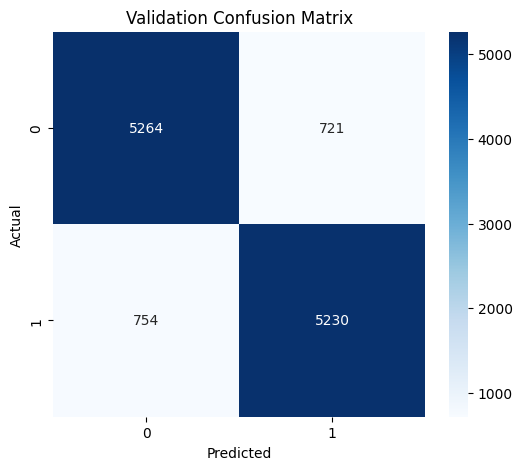

In [64]:
cm = confusion_matrix(y_valid, y_valid_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Validation Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC CURVE

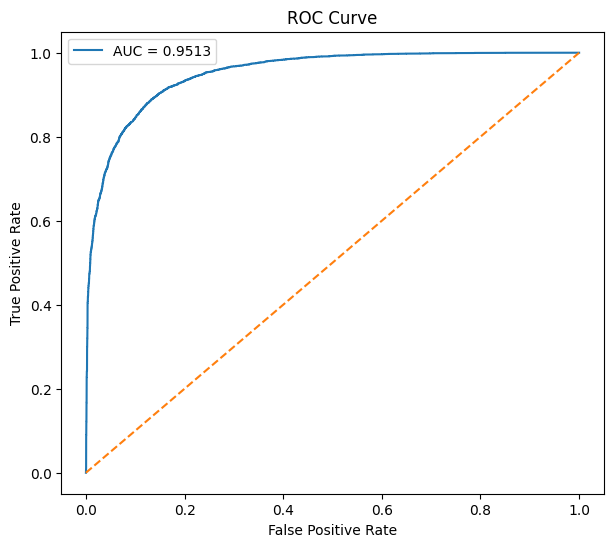

In [65]:
fpr, tpr, _ = roc_curve(y_valid, y_valid_probs)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f"AUC = {valid_auc:.4f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# TEST CONFUSION MATRIX

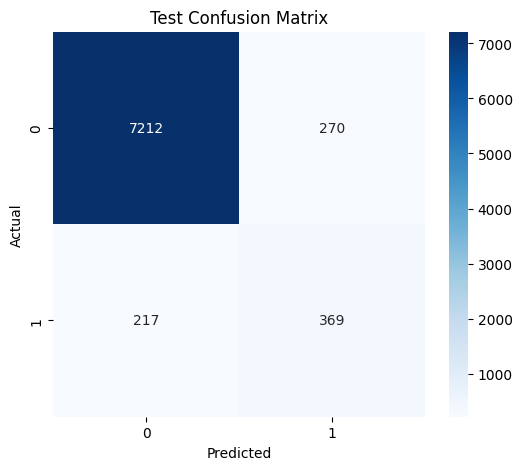

In [70]:
cm_test = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues')
plt.title('Test Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# SHAP EXPLAINABILITY

In [77]:
explainer = shap.Explainer(model, X_train[:100])  
shap_values = explainer(X_valid[:500]) 

PermutationExplainer explainer: 501it [00:28, 11.91it/s]                         


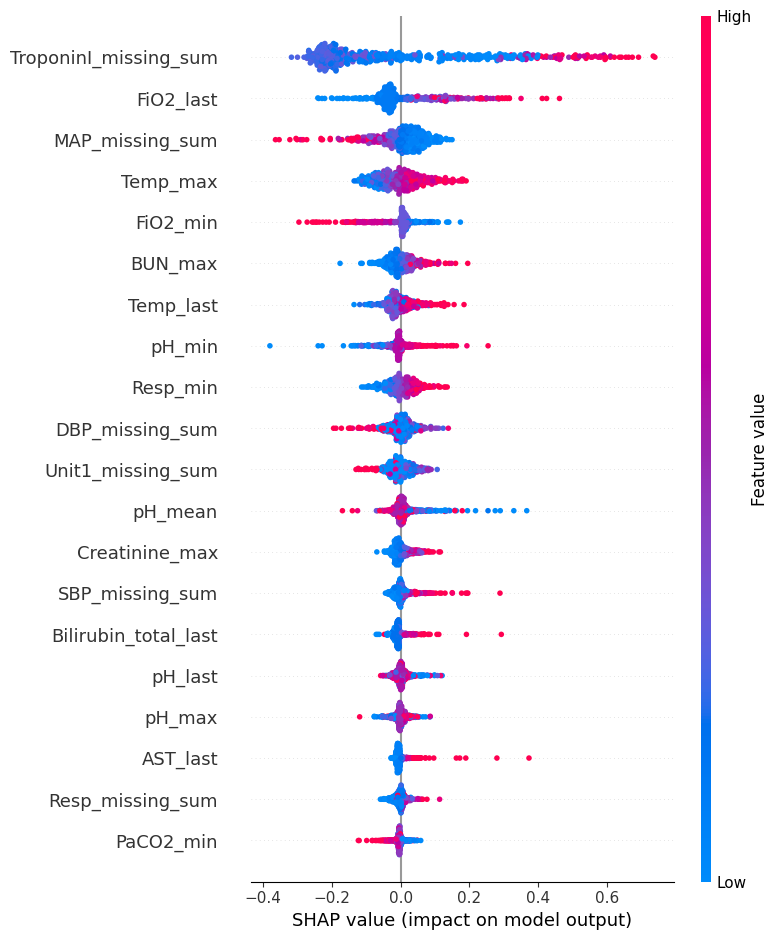

In [78]:
# summary plot

shap.summary_plot(shap_values, X_valid[:500])

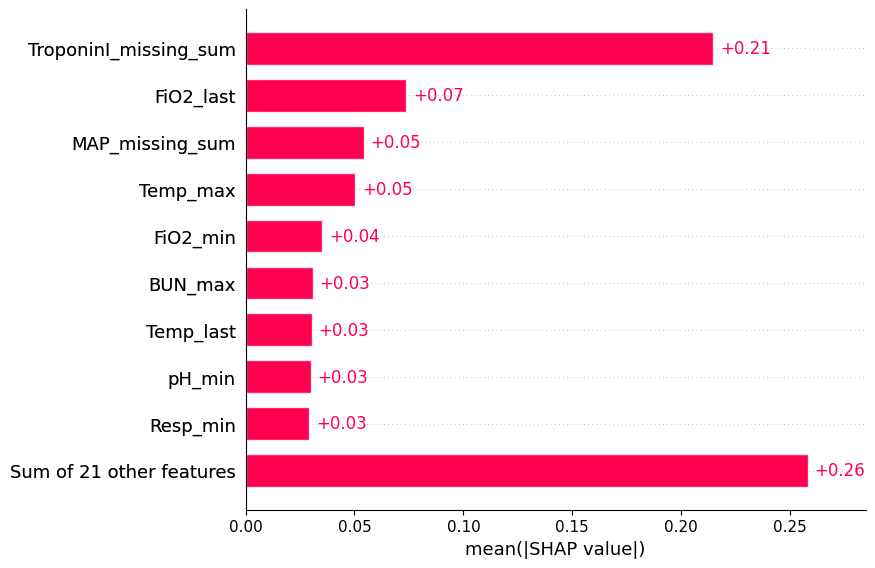

In [79]:
# Bar Plot 

shap.plots.bar(shap_values)

145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


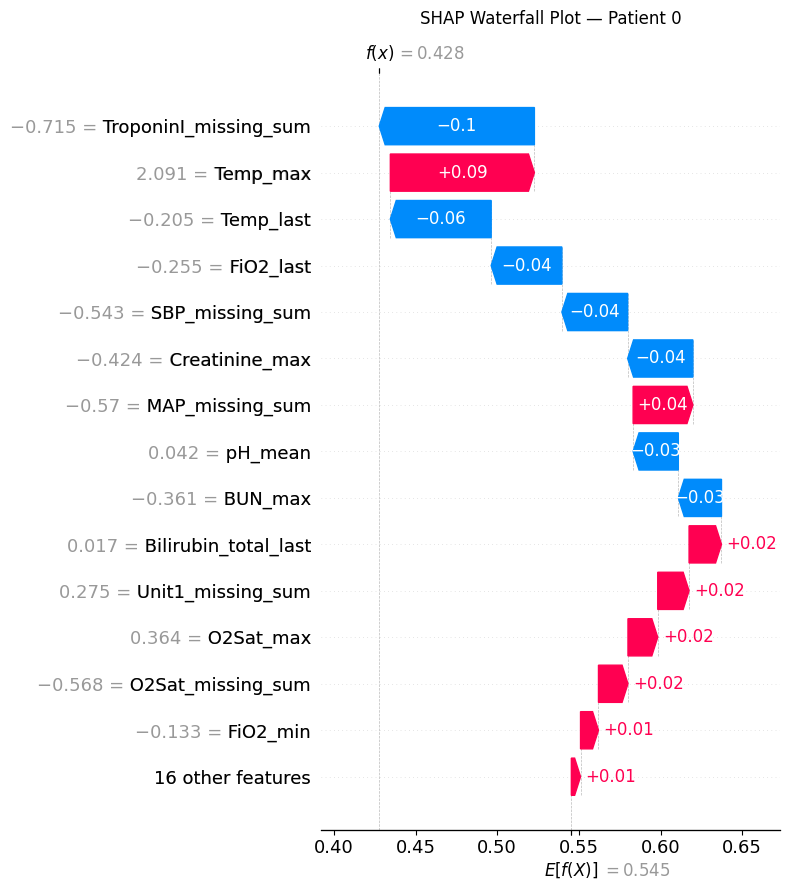

 Saved: shap_waterfall.png  |  f(x) = 0.4277


In [80]:
background = X_train.sample(100, random_state=42)


explainer = shap.Explainer(model.predict, background)


patient_idx = 0
patient_data = X_test.iloc[patient_idx : patient_idx + 1] 

# 4. Compute SHAP values 
shap_vals = explainer(patient_data)

# 5. Plot waterfall 
plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_vals[0], max_display=15, show=False)
plt.title(f"SHAP Waterfall Plot — Patient {patient_idx}", pad=14)
plt.tight_layout()
plt.savefig("shap_waterfall.png", dpi=150, bbox_inches="tight")
plt.show()


pred_prob = model.predict(patient_data, verbose=0)[0][0]
print(f" Saved: shap_waterfall.png  |  f(x) = {pred_prob:.4f}")

# LIME EXPLAINABILITY

In [81]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns,
    class_names=['Survival', 'Death'],
    mode='classification'
)

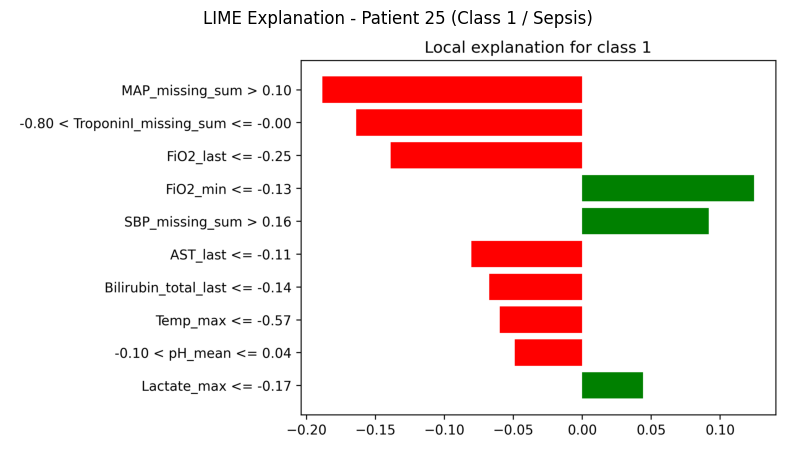

 Saved: lime_patient_25.png
   Available Labels: [1]


In [86]:
from lime.lime_tabular import LimeTabularExplainer
import numpy as np
import matplotlib.pyplot as plt


feature_names = list(X_train.columns) if hasattr(X_train, 'columns') else [f"f_{i}" for i in range(X_train.shape[1])]


explainer = LimeTabularExplainer(
    training_data=np.array(X_train),
    mode='classification',
    feature_names=feature_names,
    discretize_continuous=True,
    random_state=42
)

def predict_proba_wrapper(x):
  
    probs = model.predict(x, verbose=0)         
    return np.hstack([1 - probs, probs])         

patient_index = 25
sample = X_test.iloc[patient_index].values      


exp = explainer.explain_instance(
    data_row=sample,
    predict_fn=predict_proba_wrapper,
    num_features=10
)


fig = exp.as_pyplot_figure(label=1) 


file_name = f"lime_patient_{patient_index}.png"
fig.savefig(file_name, dpi=300, bbox_inches='tight')
plt.close(fig) 


plt.figure(figsize=(10, 6))
plt.imshow(plt.imread(file_name))
plt.axis('off')
plt.title(f"LIME Explanation - Patient {patient_index} (Class 1 / Sepsis)")
plt.show()

print(f" Saved: {file_name}")
print(f"   Available Labels: {exp.available_labels()}")

# PERMUTATION FEATURE IMPORTANCE

Calculating Permutation Importance (AUC Drop)...


Features: 100%|██████████| 30/30 [00:14<00:00,  2.05it/s]


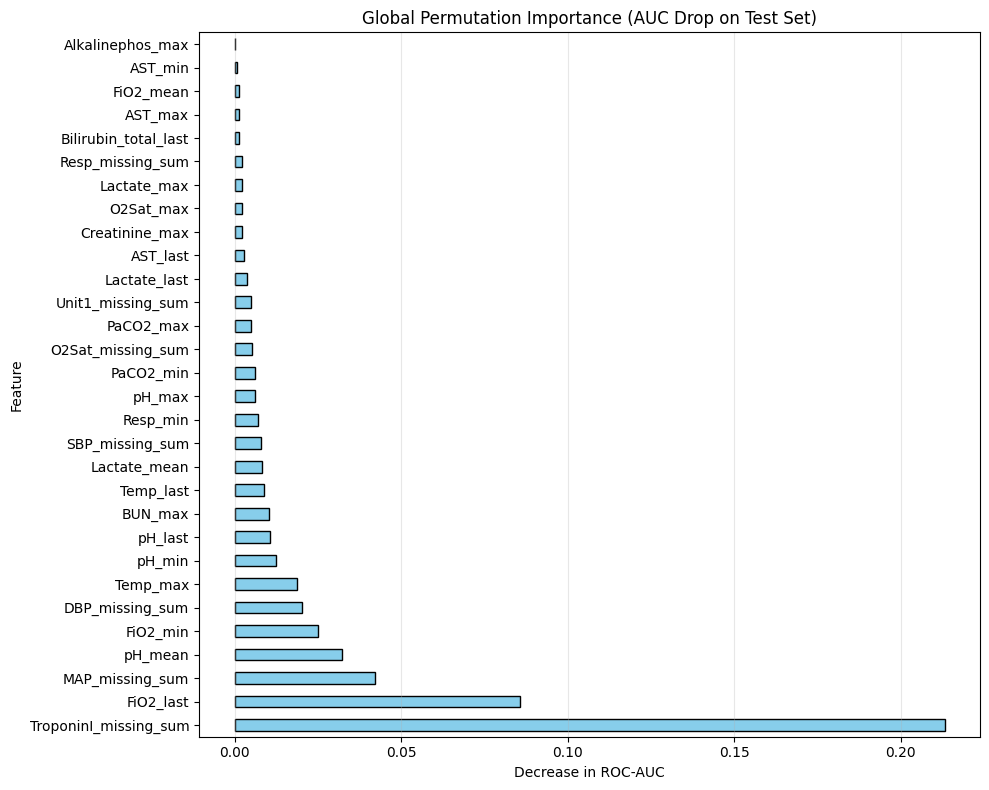


 Baseline AUC: 0.9094
Top 5 Most Important Features:
TroponinI_missing_sum    0.213126
FiO2_last                0.085656
MAP_missing_sum          0.042106
pH_mean                  0.032161
FiO2_min                 0.024901
dtype: float64


In [104]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from tqdm import tqdm  # Optional: progress bar

def calculate_permutation_importance(model, X, y, feature_names=None):
    # Fallback to DataFrame columns if not provided
    if feature_names is None:
        feature_names = X.columns.tolist() if hasattr(X, 'columns') else [f"f_{i}" for i in range(X.shape[1])]
        
    # Baseline AUC (ravel fixes Keras (N,1) -> (N,) shape mismatch)
    baseline_pred = model.predict(X, verbose=0).ravel()
    baseline_auc = roc_auc_score(y, baseline_pred)
    
    importances = {}
    
    print("Calculating Permutation Importance (AUC Drop)...")
    for i, name in enumerate(tqdm(feature_names, desc="Features")):
        X_permuted = X.copy()
        
        # Shuffle only the i-th feature column (2D DataFrame/Array safe)
        if hasattr(X, 'iloc'):
            X_permuted.iloc[:, i] = np.random.permutation(X_permuted.iloc[:, i])
        else:
            X_permuted[:, i] = np.random.permutation(X_permuted[:, i])
            
        # Measure performance drop
        perm_pred = model.predict(X_permuted, verbose=0).ravel()
        perm_auc = roc_auc_score(y, perm_pred)
        importances[name] = baseline_auc - perm_auc  # Positive = important feature
        
    return pd.Series(importances).sort_values(ascending=False)


perm_imp = calculate_permutation_importance(model, X_test, y_test)

# Visualize
plt.figure(figsize=(10, 8))
perm_imp.plot(kind='barh', color='skyblue', edgecolor='black')
plt.title("Global Permutation Importance (AUC Drop on Test Set)")
plt.xlabel("Decrease in ROC-AUC")
plt.ylabel("Feature")
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n Baseline AUC: {roc_auc_score(y_test, model.predict(X_test, verbose=0).ravel()):.4f}")
print("Top 5 Most Important Features:")
print(perm_imp.head())

# PARTIAL DEPENDENCE PLOTS

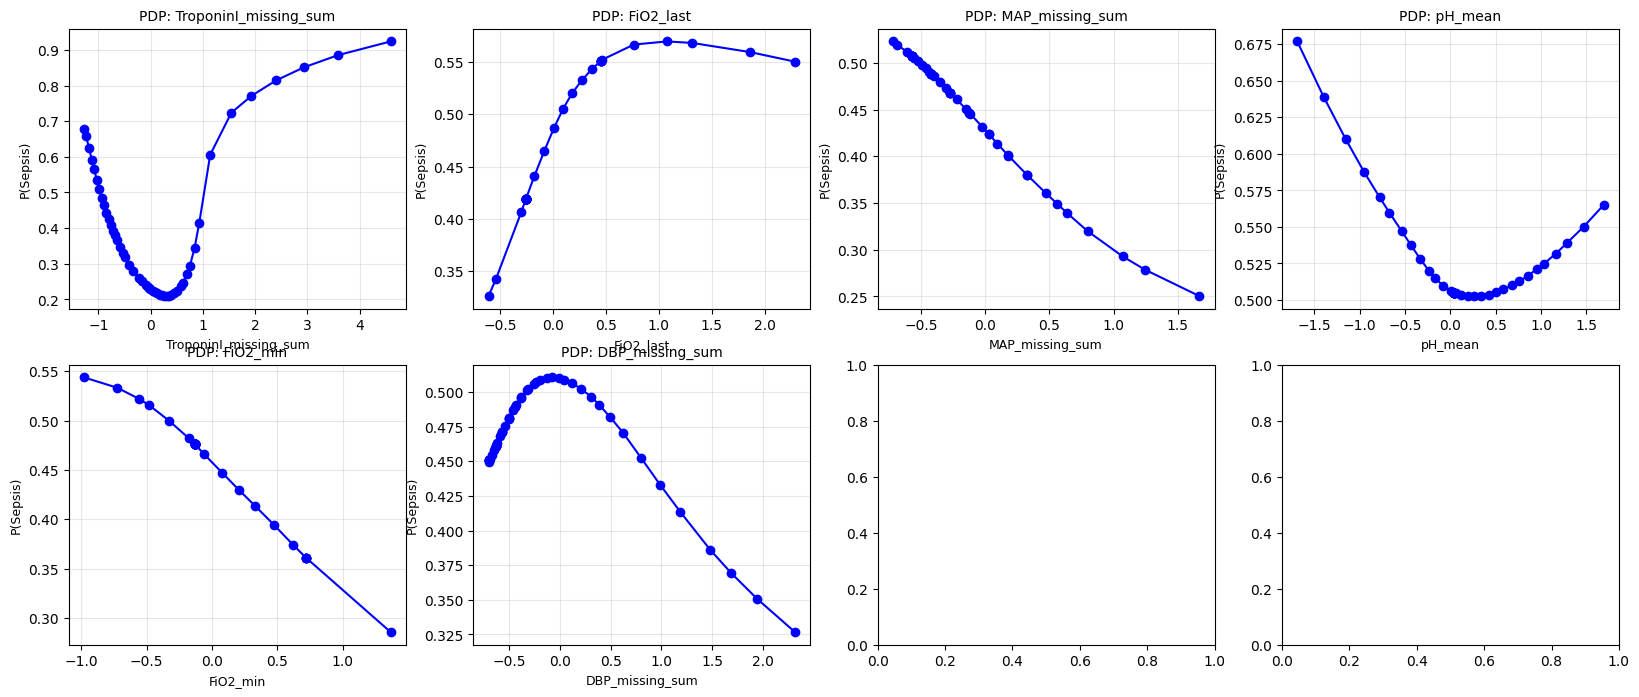

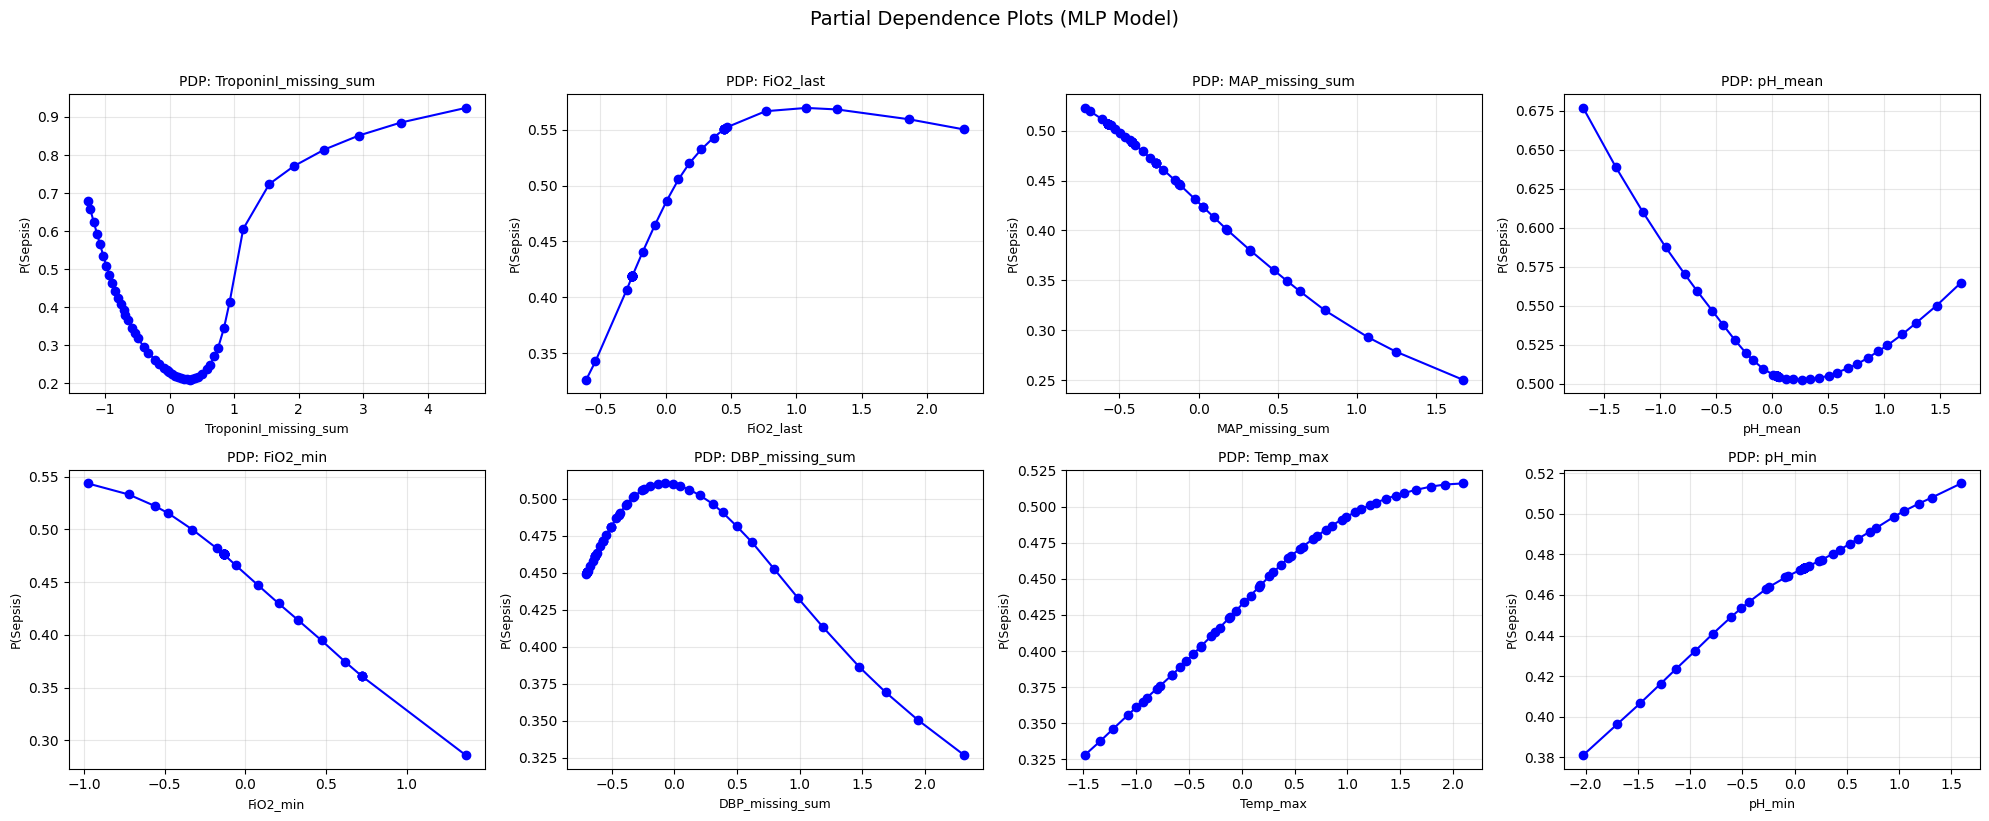

In [111]:
import numpy as np
import matplotlib.pyplot as plt

# --- 2. Correct Partial Dependence Plots for Keras ---

def compute_pdp_for_keras(model, X, feature_name, grid_resolution=50, sample_size=500):
    """
    Computes Partial Dependence Plot values for a Keras model.
    This avoids sklearn compatibility issues with Keras models.
    """
    # Sample data for faster computation
    if len(X) > sample_size:
        if hasattr(X, 'sample'):
            X_sub = X.sample(sample_size, random_state=42)
        else:
            idx = np.random.choice(len(X), sample_size, replace=False)
            X_sub = X.iloc[idx]
    else:
        X_sub = X.copy()
        
    # Create grid of values based on percentiles
    percentiles = np.linspace(5, 95, grid_resolution)
    grid_values = np.percentile(X[feature_name].values, percentiles)
    
    pd_values = []
    
    for val in grid_values:
        # Create a copy of the subset to modify
        X_temp = X_sub.copy()
        
        # Set the feature to the grid value
        if hasattr(X_temp, 'iloc'):
            X_temp[feature_name] = val
        else:
            # Find column index for numpy array
            # Assuming feature_name matches the order or we map it
            # For safety in arrays, we rely on the assumption that feature_name is in the list passed
            # If X is array, we need to know the index. 
            # Note: The function above is designed primarily for DataFrames. 
            # If X is numpy array, we need to handle index mapping.
            pass 
            
        # Prediction
        preds = model.predict(X_temp, verbose=0).ravel()
        pd_values.append(np.mean(preds))
        
    return grid_values, pd_values

def plot_pdp_grid(model, X, features, grid_resolution=50, sample_size=500, cols=4):
    """
    Plots PDPs for a list of features in a grid.
    """
    n_features = len(features)
    rows = (n_features + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
    axes = axes.ravel()
    
    for i, feature in enumerate(features):
        ax = axes[i]
        
        # Handle numpy array vs DataFrame for index finding
        if hasattr(X, 'iloc'):
            X_data = X
        else:
            # If X is array, we construct a temporary wrapper or assume order
            # It is much safer to use a DataFrame for this function.
            # If X_test is passed, it is likely a DataFrame.
            X_data = X 
            
        x_vals, y_vals = compute_pdp_for_keras(model, X_data, feature, grid_resolution, sample_size)
        
        ax.plot(x_vals, y_vals, marker='o', linestyle='-', color='b')
        ax.set_xlabel(feature, fontsize=9)
        ax.set_ylabel("P(Sepsis)", fontsize=9)
        ax.set_title(f'PDP: {feature}', fontsize=10)
        ax.grid(True, alpha=0.3)
        
    # Hide empty subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
        
    plt.suptitle("Partial Dependence Plots (MLP Model)", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

# Execution Example: Plot PDP for the top 5 most important features
# Ensure 'perm_imp' was calculated from the previous cell
top_features = perm_imp.index[:8] # Selecting top 8 for demonstration

# NOTE: Ensure X_valid is available in your environment. 
# The function expects a DataFrame or compatible array.
plot_pdp_grid(model, X_valid, top_features)

# SAVE MODEL

In [112]:
model.save("sepsis_mlp_model.h5")

print("\nModel saved successfully!")


Model saved successfully!
